In [1]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
 
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
 
import torch
from datasets import DatasetDict, Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
import evaluate
import pickle
from datasets import load_from_disk

warnings.filterwarnings("ignore")

In [2]:
encoded_dataset = load_from_disk("title_classifier_encoded_dataset.hf")  
# encoded_dataset.set_format("torch")

In [3]:
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(device)

mps


In [4]:
encoded_dataset.set_format("torch", device=device)

## Load the Encoder

In [5]:
import pickle
with open("/Users/philip.juachon/Desktop/Personal Learning/Deep Learning/final-project/artifacts/02_y_encoder.pkl", "rb") as f:
    y_encoder = pickle.load(f)

## Finetuning Proper

In [6]:
labels = y_encoder.classes_
id2label = {idx: label for idx, label in enumerate(labels)}
label2id = {label: idx for idx, label in enumerate(labels)}
NUM_LABELS = len(labels)

In [7]:
def compute_metrics(eval_pred):
    logits, true_labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    
    f1 = f1_score(true_labels, predictions, average='weighted')
    acc = accuracy_score(true_labels, predictions)
    return {"accuracy": acc, "f1": f1}

In [8]:
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", 
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id
)

model = model.to(device)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [9]:
WEIGHT_DECAY = 0.01
SEED = 69
BATCH_SIZE = 16
EPOCHS = 5
LEARNING_RATE = 2e-5
LOGGING_STEPS = 50

training_args = TrainingArguments(
    output_dir="/Users/philip.juachon/Desktop/Personal Learning/Deep Learning/final-project/output/results_base_model",
    learning_rate=LEARNING_RATE,              
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,
    num_train_epochs=EPOCHS,              
    weight_decay = WEIGHT_DECAY,
    seed = SEED,
    logging_steps = LOGGING_STEPS,
    eval_strategy="epoch",     
    save_strategy="epoch",           
    load_best_model_at_end=True,     
    metric_for_best_model="f1"
)

In [10]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encoded_dataset["train"],
    eval_dataset=encoded_dataset["validation"],
    compute_metrics=compute_metrics
)

In [11]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.889679,0.831919,0.755023,0.750493
2,0.681476,0.814393,0.764759,0.759408
3,0.547414,0.863109,0.765720,0.764117
4,0.385241,0.939103,0.762867,0.760491
5,0.224889,1.005600,0.761379,0.759976


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=40315, training_loss=0.5605612713542807, metrics={'train_runtime': 29713.2817, 'train_samples_per_second': 21.708, 'train_steps_per_second': 1.357, 'total_flos': 4.27402467571968e+16, 'train_loss': 0.5605612713542807, 'epoch': 5.0})

In [12]:
print("\nEvaluating on Test Set...")
print(trainer.evaluate(encoded_dataset["test"]))


Evaluating on Test Set...


{'eval_loss': 0.8684389591217041, 'eval_accuracy': 0.7615527719211211, 'eval_f1': 0.7595397077061482, 'eval_runtime': 486.306, 'eval_samples_per_second': 82.9, 'eval_steps_per_second': 2.591, 'epoch': 5.0}


In [ ]:
test_output = trainer.predict(encoded_dataset["test"])
predictions = np.argmax(test_output.predictions, axis=-1)
print(predictions)

In [14]:
print(f"\n── Test set evaluation Headline + Short Description) ──")
test_output = trainer.predict(encoded_dataset["test"])
preds = np.argmax(test_output.predictions, axis=-1)


── Test set evaluation Headline + Short Description) ──


In [15]:
labels = test_output.label_ids

In [16]:
labels

array([14, 16,  6, ..., 12, 16, 22])

In [18]:
report = classification_report(
    labels, preds,
    target_names=y_encoder.classes_,
    digits=4,
    zero_division=0,
)
print(report)

                precision    recall  f1-score   support

ARTS & CULTURE     0.6267    0.6339    0.6303       784
  BLACK VOICES     0.5849    0.5000    0.5391       916
      BUSINESS     0.6158    0.6985    0.6546      1549
        COMEDY     0.6062    0.5640    0.5843      1078
         CRIME     0.6681    0.6653    0.6667       711
       DIVORCE     0.7842    0.8392    0.8107       684
 ENTERTAINMENT     0.7781    0.7756    0.7769      3472
   ENVIRONMENT     0.6053    0.6761    0.6387       812
  FOOD & DRINK     0.8662    0.8251    0.8452      1687
 HOME & LIVING     0.7941    0.8497    0.8209       858
        IMPACT     0.5163    0.3879    0.4430       696
         MEDIA     0.6393    0.5034    0.5633       588
     PARENTING     0.8157    0.7816    0.7983      2532
      POLITICS     0.8286    0.8422    0.8353      7117
  QUEER VOICES     0.8184    0.7494    0.7824      1269
      RELIGION     0.6364    0.6401    0.6382       514
SCIENCE & TECH     0.5962    0.6185    0.6071  

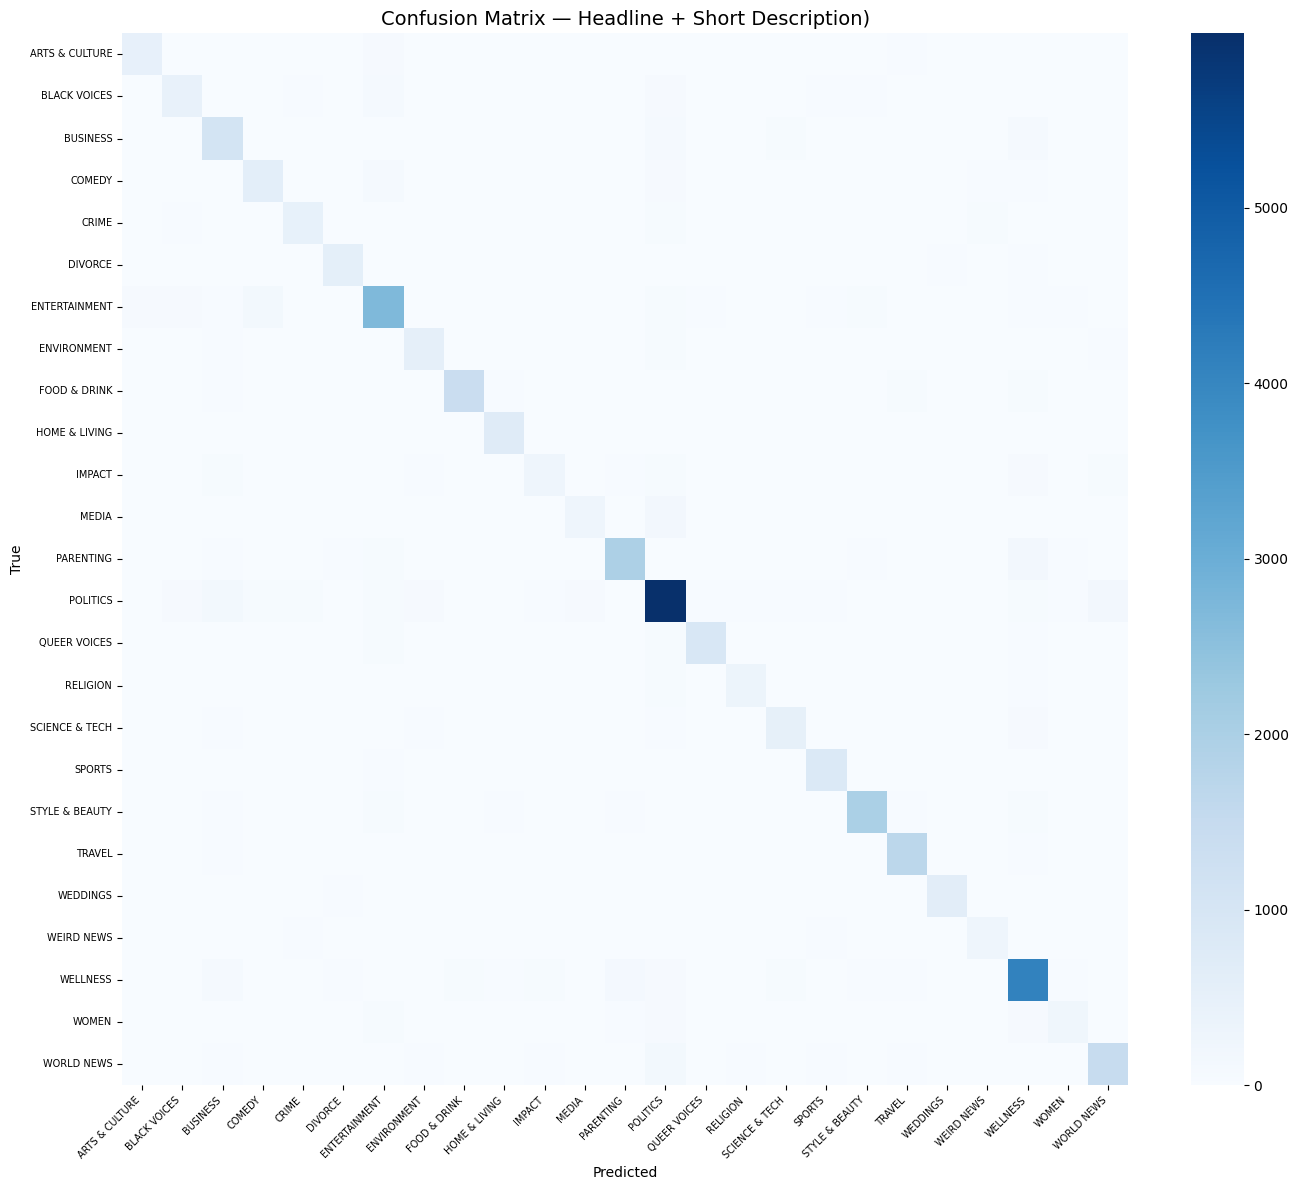

In [20]:
cm = confusion_matrix(labels, preds)
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    cm, annot=False, fmt='d', cmap='Blues',
    xticklabels=y_encoder.classes_, yticklabels=y_encoder.classes_, ax=ax
)
ax.set_title(f"Confusion Matrix — Headline + Short Description)", fontsize=14)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()